In [254]:
# !pip install python-dotenv langchain langchain-core langchain-community langchain-google-genai chromadb langchain-text-splitters beautifulsoup4 sentence-transformers einops langchainhub langsmith faiss-cpu pydantic rank_bm25 sentence-transformers 
# !pip install langchain-google-vertexai

## Declaration

In [255]:
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.documents import Document
from langchain_core.output_parsers import JsonOutputParser
import transformers
import json
import numpy as np
import os
import warnings
from dotenv import load_dotenv
from pydantic import BaseModel
from typing import List
from langchain_community.retrievers import BM25Retriever
from langgraph.graph import StateGraph, END
from pydantic import BaseModel
from typing import TypedDict, List
from sentence_transformers import CrossEncoder
from langchain_community.embeddings import HuggingFaceEmbeddings
from langchain_community.vectorstores import Chroma
import time
import vertexai
from langchain_google_vertexai import ChatVertexAI
from sklearn.metrics.pairwise import cosine_similarity



load_dotenv()
google_api_key = os.getenv("GOOGLE_API_KEY")
langchain_api_key = os.getenv("LANGCHAIN_API_KEY")
hf_token = os.getenv("HUGGINGFACEHUB_API_TOKEN")
os.environ["LANGCHAIN_TRACING_V2"] = "true"
os.environ["LANGCHAIN_ENDPOINT"] = "https://api.smith.langchain.com"
warnings.filterwarnings("ignore")

class QueryOutput(BaseModel):
    rewritten_query: str
    expanded_queries: List[str]
    step_back_query: str

class QueryOptimizerOutput(BaseModel):
    rewritten_query: str
    expanded_queries: List[str]
    step_back_query: str

class GraphState(TypedDict):
    query: str
    rewritten_query: str
    expanded_queries: List[str]
    step_back_query: str
    documents: List[Document]
    answer: str
    iteration: int
    retrieval_feedback: dict
    doc_scores: List[float]
    grounded_statements: List[str]
    evidence_units: List[str]


### Models

In [256]:
vertexai.init(project="ai-rag-automation", location="global")
llm_compression = ChatVertexAI( model="gemini-3-flash-preview" )
llm = ChatVertexAI( model="gemini-3-flash-preview" )

structured_llm = llm.with_structured_output(QueryOutput)
cross_encoder = CrossEncoder("cross-encoder/ms-marco-MiniLM-L-6-v2")
embeddings = HuggingFaceEmbeddings(model_name="nomic-ai/nomic-embed-text-v1",model_kwargs={"trust_remote_code": True})


Loading weights: 100%|██████████| 105/105 [00:00<00:00, 8922.42it/s]
BertForSequenceClassification LOAD REPORT from: cross-encoder/ms-marco-MiniLM-L-6-v2
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Unrecognized keys in `rope_parameters` for 'rope_type'='dynamic': {'rope_theta'}
<All keys matched successfully>
Unrecognized keys in `rope_parameters` for 'rope_type'='dynamic': {'rope_theta'}


In [257]:
import random

def safe_llm_invoke(llm, prompt, retries=1):
    last_error = None

    for i in range(retries):
        try:
            return llm.invoke(prompt)
        except Exception as e:
            last_error = e
            wait_time = (2 ** i) + random.uniform(0, 1)
            print(f"[Retry {i+1}] Waiting {wait_time:.2f}s →", repr(e))
            time.sleep(wait_time)

    raise last_error

## Query Rewritting & Expansion

* User Query  ->  Query Rewriting  ->  Step-Back Query  ->  Query Expansion


| Step      | Why                                      |
| --------- | ---------------------------------------- |
| Rewrite   | cleans the query and removes ambiguity   |
| Step-back | captures **higher-level concept**        |
| Expansion | generates **multiple search variations** |


In [258]:
optimizer_prompt = ChatPromptTemplate.from_messages([
    ("system", "You are an expert query optimizer. Return ONLY JSON."),
    ("human", """
        User Query:
        {query}

        Perform:
        1. Rewrite query
        2. Generate 3 variations
        3. Generate step-back query

        Return JSON:

        {{
        "rewritten_query": "...",
        "expanded_queries": ["...", "...", "...", "..."],
        "step_back_query": "..."
        }}
    """)
])

def query_intelligence_node(state):

    iteration = state.get("iteration", 0)

    # PASS 1 (normal)
    if iteration == 0:
        query = state["query"]

        prompt = optimizer_prompt.invoke({
            "query": query
        })

    # PASS 2 (feedback-driven)
    else:
        feedback = state.get("retrieval_feedback", {})

        snippets = [
            doc.page_content[:200] 
            for doc in state.get("documents", [])[:2]
        ]

        refined_query = f"""
            Previous retrieval failed.

            Reason: {feedback.get("reason")}
            Max Score: {feedback.get("max_score")}
            Avg Score: {feedback.get("avg_score")}

            The following snippets were retrieved but are NOT relevant:
            {chr(10).join(snippets)}

            IMPORTANT:
            - These snippets are incorrect or irrelevant
            - Do NOT base your query on them
            - Use them only to understand what went wrong

            Original Query:
            {state["query"]}

            Previous Rewritten Query:
            {state.get("rewritten_query")}

            Previous Expanded Query:
            {state.get("expanded_queries")}

            Previous Step_back Query:
            {state.get("step_back_query")}

            Your task:
            - Identify why retrieval failed
            - Fix the query without drifting away from user intent
            - Preserve original intent strictly
            - Improve specificity and keywords
        """
        
        prompt = optimizer_prompt.invoke({
            "query": refined_query
        })

    result = safe_llm_invoke(structured_llm,prompt)
    print("Query: ",state["query"])
    print("Rewritten_query: ",result.rewritten_query)
    print("Expanded_queries: ",result.expanded_queries)
    print("Step_back_query: ",result.step_back_query)

    return {
        "rewritten_query": result.rewritten_query,
        "expanded_queries": result.expanded_queries,
        "step_back_query": result.step_back_query,
    }




## VECTOR-DB, EMBEDDINGS & INGESTION

In [259]:

# documents = [
#     Document(page_content="RAG systems retrieve documents before generation."),
#     Document(page_content="Faithfulness measures whether answers are grounded in retrieved documents."),
#     Document(page_content="Query expansion improves recall in retrieval systems."),
# ]

documents = [

    # Core RAG
    Document(page_content="RAG systems retrieve relevant documents before generating responses."),
    Document(page_content="RAG combines retrieval and generation to improve factual accuracy."),
    
    # Faithfulness
    Document(page_content="Faithfulness measures whether generated answers are grounded in retrieved documents."),
    Document(page_content="Low faithfulness indicates hallucination in generated responses."),
    
    # Retrieval improvements
    Document(page_content="Query expansion improves recall in retrieval systems by adding related terms."),
    Document(page_content="Better recall increases the chance of retrieving relevant documents."),
    
    # Noise / distractors (important for testing)
    Document(page_content="Precision measures how many retrieved documents are relevant."),
    Document(page_content="Large language models are trained on vast amounts of data."),
    
    # Multi-hop bridge facts
    Document(page_content="Improving retrieval quality can lead to better grounded answers."),
    Document(page_content="Grounded answers depend on the quality of retrieved documents."),
    
    # Subtle overlap
    Document(page_content="Hallucination occurs when a model generates information not present in the context."),
]

vectorstore = Chroma.from_documents(
    documents=documents,
    collection_name="verirag-chroma",
    embedding=embeddings,
)

vector_retriever = vectorstore.as_retriever(search_kwargs={"k": 5})
bm25_retriever = BM25Retriever.from_documents(documents)
bm25_retriever.k = 5

## RETRIEVER

In [260]:
# Retrieve top 5 results from both BM25 and Vector retrievers, then deduplicate results
def hybrid_retrieve_node(state):
    queries = (
        [state["rewritten_query"]] +
        state["expanded_queries"] +
        [state["step_back_query"]]
    )

    all_docs = []
    print("----------------------------")
    for q in queries:
        print("Query: ",q)
        all_docs.extend(bm25_retriever.invoke(q))
        all_docs.extend(vector_retriever.invoke(q))
        print(all_docs)
        
    print("----------------------------")
    # Deduplicate
    unique_docs = list({doc.page_content: doc for doc in all_docs}.values())

    return {"documents": unique_docs}

## Cross Encoder & Re-Ranking

In [261]:
# Rerank retrieved documents using cross-encoder, normalised scores and filter out low-relevance docs based on a threshold
def rerank_and_filter_node(state):

    docs = state.get("documents", [])
    query = state["query"]

    if not docs:
        return {
            "documents": [],
            "answer": "I don't know",
            "retrieval_feedback": {"reason": "no_docs"}
        }

    pairs = [(query, doc.page_content) for doc in docs]
    scores = cross_encoder.predict(pairs)
    scores = 1 / (1 + np.exp(-scores))

    doc_scores = list(zip(docs, scores))
    doc_scores.sort(key=lambda x: x[1], reverse=True)

    top_docs = doc_scores[:5]
    top_scores = [score for _, score in top_docs]
    max_score = max(top_scores)
    avg_score = sum(top_scores) / len(top_scores)
    print(top_scores, max_score, avg_score)
    print("----------------------------")

    print("rerank: ",[doc for doc, _ in top_docs])
    print("--------------------------------------")

    upper_threshold = 0.6
    lower_threshold = 0.4
    

    if max_score < lower_threshold:
        print("below lower threshold")
        return {
            "documents": [doc for doc, _ in top_docs],
            "answer": "I don't know"
        }

    elif max_score < upper_threshold:
        print("below upper threshold")
        return {
            "documents": [doc for doc, _ in top_docs],
            "doc_scores": top_scores,
            "retrieval_feedback": {
                "reason": "low_relevance",
                "max_score": float(max_score),
                "avg_score": float(avg_score)
            }
        }
    else:
        print("above upper threshold")
        return {
            "documents": [doc for doc, _ in top_docs],
            "doc_scores": top_scores
        }

In [262]:
def Retry_decision_logic(state):

    iteration = state.get("iteration", 0)
    max_iterations = 3
    print("HELLOW: ",iteration," ---> ", state.get("retrieval_feedback"))

    if state.get("retrieval_feedback") != None and iteration < max_iterations:
        return "retry"

    # If no docs → retry
    if not state.get("documents") and iteration < max_iterations:
        return "retry"

    return "generate"

def Refine_query_node(state):
    return {
        "iteration": state.get("iteration", 0) + 1
    }

In [263]:
def extract_text(response):
    content = response.content

    if isinstance(content, list):
        return " ".join([item.get("text", "") for item in content]).strip()
    
    return content.strip()


def compress_documents_node(state):

    query = state["query"]
    docs = state.get("documents", [])[:3]

    if not docs:
        return {"documents": []}

    # Embed query once
    query_embedding = embeddings.embed_query(query)

    compressed_docs = []

    total_original_tokens = 0
    total_compressed_tokens = 0

    for doc in docs:

        text = doc.page_content

        # Rough token count (interview acceptable approximation)
        total_original_tokens += len(text.split())

        # Step 1: sentence splitting (simple but effective)
        sentences = [s.strip() for s in text.split(".") if len(s.strip()) > 10]

        if not sentences:
            compressed_docs.append(doc)
            continue

        # Step 2: embed sentences
        sentence_embeddings = embeddings.embed_documents(sentences)

        # Step 3: similarity scoring
        scores = cosine_similarity(
            [query_embedding],
            sentence_embeddings
        )[0]

        # Step 4: pick top-k sentences
        top_k = min(3, len(sentences))

        top_indices = np.argsort(scores)[-top_k:]
        top_indices = sorted(top_indices)  # preserve order

        selected_sentences = [sentences[i] for i in top_indices]

        compressed_text = ". ".join(selected_sentences)

        total_compressed_tokens += len(compressed_text.split())

        compressed_docs.append(Document(page_content=compressed_text))

    # 🔥 LOGGING (THIS is what impresses interviewers)
    print("📉 Compression Stats:")
    print(f"Original tokens: {total_original_tokens}")
    print(f"Compressed tokens: {total_compressed_tokens}")

    if total_original_tokens > 0:
        reduction = 1 - (total_compressed_tokens / total_original_tokens)
        print(f"Reduction: {reduction:.2%}")
    
    print(compressed_docs)
    print(state.get("answer"))
    print("--------------------------------------")
    return {"documents": compressed_docs}

## ANSWER PLANNER

In [264]:
# answer_planner_prompt = ChatPromptTemplate.from_messages([
#     ("system", "You are an answer planner. Break the question into atomic factual claims. Return ONLY JSON."),
#     ("human", """
#     Question:
#     {query}

#     Generate 3-5 factual claims needed to answer this question.

#     Rules:
#     - Each claim must be verifiable from documents
#     - Keep them atomic (no compound claims)

#     Output:
#     {{
#         "claims": ["...", "..."]
#     # }
#     """)
# ])

# def answer_planner_node(state):
#     prompt = answer_planner_prompt.invoke({"query": state["query"]})
    
#     response = structured_llm.invoke(prompt)
    
#     return {
#         "claims": response.claims
#     }

## CLAIM AWARE GENERATION

In [265]:
# claim_generation_prompt = ChatPromptTemplate.from_template("""
# You are a strict factual assistant.

# Claim:
# {context}

# Context:
# {context}

# Instructions:
# - Verify if the claim is supported by context
# - If YES → rewrite it as a grounded statement
# - If NO → say "NOT SUPPORTED"

# Output:
# """)

# def claim_aware_generation_node(state):

#     # claims = state.get("claims", [])
#     docs = state.get("documents", [])

#     claims = "\n".join([doc.page_content for doc in docs])

#     # verified_claims = []

#     for claim in claims:
#         prompt = claim_generation_prompt.invoke({
#             "claim": claim,
#             "context": context
#         })

#         response = safe_llm_invoke(llm, prompt)
#         text = extract_text(response)

#         if "NOT SUPPORTED" not in text:
#             verified_claims.append(text)

#     print("Verified_claims:", verified_claims)
#     return {
#         "verified_claims": verified_claims
#     }

In [266]:
# def final_answer_node(state):

#     claims = state.get("verified_claims", [])

#     if not claims:
#         return {"answer": "I don't know"}

#     return {
#         "answer": "\n".join(claims)
#     }

## GENERATION

In [267]:
def evidence_selection_node(state):

    query = state["query"]
    docs = state.get("documents", [])

    selected_evidence = []
    for doc in docs:
        prompt = f"""
        Query: {query}

        Document:
        {doc.page_content}

        Is this document useful for answering the query in any meaningful manner?

        Answer YES or NO and briefly justify your choice.
        """

        response = safe_llm_invoke(llm, prompt)
        text = extract_text(response)
        print(f"Response for {doc}: {text}")
        if "YES" in text.upper():
            selected_evidence.append(doc.page_content)
    print("Evidence Units:", selected_evidence)
    return {
        "evidence_units": selected_evidence
    }

In [268]:
def evidence_grounded_generation_node(state):
    query = state["query"]
    evidence_units = state.get("evidence_units", [])

    grounded_statements = []

    for doc in evidence_units:
        prompt = f"""
        Based ONLY on the following document, extract a factual statement 
        that helps answer the question.
        Query: {query}

        Document:
        {doc}

        Rules:
        - Do not hallucinate
        - Do not add external knowledge
        - Keep it concise and factual
        """

        response = safe_llm_invoke(llm, prompt)
        text = extract_text(response)

        grounded_statements.append(text)
    print("Grounded Statements:", grounded_statements)
    return {
        "grounded_statements": grounded_statements
    }

In [269]:
generation_prompt = ChatPromptTemplate.from_template(
"""
    You are a strict assistant.
    Answer ONLY using the provided context and statements.
    If the answer is not clearly present, say "I don't know, but in future iterations, I will try to find more relevant information."

    Question:
    {query}

    Context:
    {context}

    Combine the following grounded statements into the response generated using Question and Context so as to increase trustworthiness of your answer:
    {claims}

    Rules:
    - Stay faithful to statements
    - Do not introduce new facts

    Answer:
"""
)
def generate_answer_node(state):

    # If reranker already decided to stop
    if state.get("answer") == "I don't know":
        return {"answer": "I don't know"}

    docs = state.get("documents", [])

    if not docs:
        return {"answer": "I don't know"}
    
    statements = state.get("grounded_statements", [])

    if not statements:
        return {"answer": "I don't know"}

    context = "\n\n".join([doc.page_content for doc in docs])

    prompt = generation_prompt.format(
        query=state["query"],
        context=context,
        claims=statements
    )

    response = safe_llm_invoke(llm,prompt)

    return {"answer": response.content}

## Graph Compliation

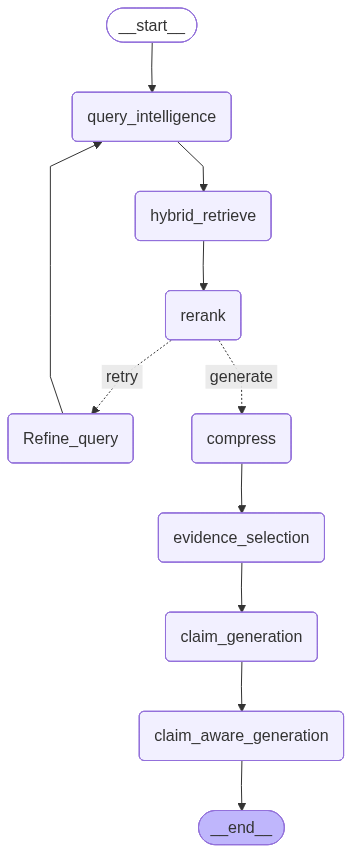

In [275]:
builder = StateGraph(GraphState)

builder.add_node("query_intelligence", query_intelligence_node)
builder.add_node("hybrid_retrieve", hybrid_retrieve_node)
builder.add_node("rerank", rerank_and_filter_node)
builder.add_node("Refine_query", Refine_query_node)
# builder.add_node("generate", generate_answer_node)
builder.add_node("compress", compress_documents_node)
builder.add_node("evidence_selection", evidence_selection_node)
builder.add_node("claim_generation", evidence_grounded_generation_node)
builder.add_node("claim_aware_generation", generate_answer_node)
# builder.add_node("final_answer", final_answer_node)

builder.set_entry_point("query_intelligence")

builder.add_edge("query_intelligence", "hybrid_retrieve")
builder.add_edge("hybrid_retrieve", "rerank")
# builder.add_edge("compress", "generate")
builder.add_edge("compress", "evidence_selection")
builder.add_edge("evidence_selection", "claim_generation")
builder.add_edge("claim_generation", "claim_aware_generation")


builder.add_conditional_edges(
    "rerank",
    Retry_decision_logic,
    {
        "retry": "Refine_query",
        "generate": "compress"
        # "generate": "generate"
    }
)

builder.add_edge("Refine_query", "query_intelligence")
builder.add_edge("claim_aware_generation", END)

graph = builder.compile()

from IPython.display import Image, display # type: ignore
display(Image(graph.get_graph(xray=True).draw_mermaid_png()))

## Inferencing RAG

In [272]:
result = graph.invoke({
    # "query": "How do we measure faithfulness in computer terminal?",
    # "query":"Explain how retrieval works in RAG systems and how faithfulness is evaluated. Also mention any technique that improves retrieval performance.",
    # "query": "Hi, what's my name?",
    # "query": "How do we measure faithfulness in RAG LLM?",
    "query" : "Explain how retrieval quality affects faithfulness in RAG systems, and mention any techniques that can improve retrieval.",
    "iteration": 0
})
print(result["answer"])

Query:  Explain how retrieval quality affects faithfulness in RAG systems, and mention any techniques that can improve retrieval.
Rewritten_query:  Analyze the relationship between retrieval performance and the faithfulness of generated responses in Retrieval-Augmented Generation (RAG) frameworks, including optimization strategies for the retrieval component.
Expanded_queries:  ['The correlation between document relevance and hallucination rates in RAG systems.', 'State-of-the-art retrieval enhancement techniques like cross-encoders, hybrid search, and re-ranking for RAG.', 'How does noise in retrieved context impact the factual accuracy and faithfulness of large language model outputs?']
Step_back_query:  What are the core challenges in building reliable Retrieval-Augmented Generation systems?
----------------------------
Query:  Analyze the relationship between retrieval performance and the faithfulness of generated responses in Retrieval-Augmented Generation (RAG) frameworks, includ

In [273]:
result["answer"][0]['text']

"Improving retrieval quality can lead to better grounded answers, and faithfulness measures whether answers are grounded in retrieved documents. However, the provided document does not contain information regarding how retrieval quality affects faithfulness or mention any specific techniques to improve retrieval. I don't know, but in future iterations, I will try to find more relevant information."

In [ ]:
def answer_planner():
    prompt = """
        
    """